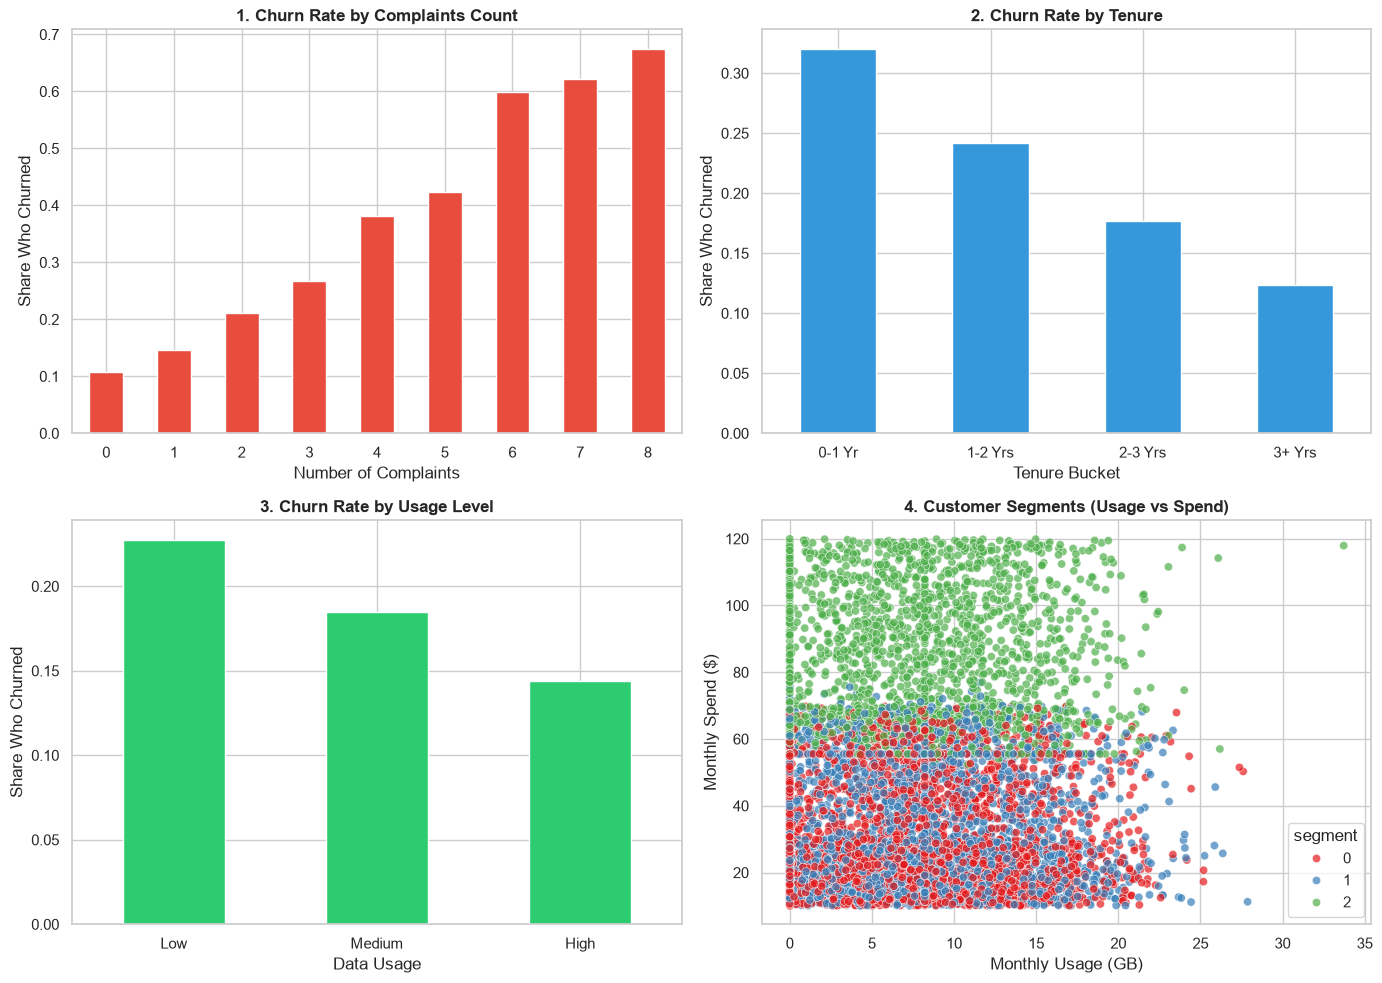

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


df = pd.read_csv('../data/features_df.csv')

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))


df.groupby("complaints_count")["is_churned"].mean().plot.bar(
    ax=axes[0, 0], color="#e74c3c"
)
axes[0, 0].set_title("1. Churn Rate by Complaints Count", fontsize=12, fontweight="bold")
axes[0, 0].set_xlabel("Number of Complaints")
axes[0, 0].set_ylabel("Share Who Churned")
axes[0, 0].tick_params(axis="x", rotation=0)


df['tenure_bucket'] = pd.cut(df['tenure_months'], bins=[0, 12, 24, 36, 100], labels=['0-1 Yr', '1-2 Yrs', '2-3 Yrs', '3+ Yrs'])
df.groupby("tenure_bucket", observed=False)["is_churned"].mean().plot.bar(
    ax=axes[0, 1], color="#3498db"
)
axes[0, 1].set_title("2. Churn Rate by Tenure", fontsize=12, fontweight="bold")
axes[0, 1].set_xlabel("Tenure Bucket")
axes[0, 1].set_ylabel("Share Who Churned")
axes[0, 1].tick_params(axis="x", rotation=0)


df['usage_bucket'] = pd.qcut(df['monthly_usage_gb'], q=3, labels=['Low', 'Medium', 'High'])
df.groupby("usage_bucket", observed=False)["is_churned"].mean().plot.bar(
    ax=axes[1, 0], color="#2ecc71"
)
axes[1, 0].set_title("3. Churn Rate by Usage Level", fontsize=12, fontweight="bold")
axes[1, 0].set_xlabel("Data Usage")
axes[1, 0].set_ylabel("Share Who Churned")
axes[1, 0].tick_params(axis="x", rotation=0)


seg_cols = ["monthly_usage_gb", "monthly_spend", "tenure_months"]
seg_df = df.dropna(subset=seg_cols).copy() 


Xs = StandardScaler().fit_transform(seg_df[seg_cols])
seg_df["segment"] = KMeans(n_clusters=3, n_init=10, random_state=42).fit_predict(Xs)


sns.scatterplot(
    data=seg_df, 
    x="monthly_usage_gb", 
    y="monthly_spend",
    hue="segment", 
    palette="Set1", 
    alpha=0.7, 
    ax=axes[1, 1]
)
axes[1, 1].set_title("4. Customer Segments (Usage vs Spend)", fontsize=12, fontweight="bold")
axes[1, 1].set_xlabel("Monthly Usage (GB)")
axes[1, 1].set_ylabel("Monthly Spend ($)")

plt.tight_layout()
plt.show()